### Imports

In [1]:
import json
from pathlib import Path

import optuna
import torch
from torch import nn

from src.config import CONFIG
from src.datasets.spike_dataset import SpikeDataset
from src.engine import benchmark_snn, train_one_epoch_snn, validate_snn, get_split_dataloaders
from src.models.snn_1d_encoded_classifier import SNN1DEncodedClassifier
from src.utils import plot_training_history, run_sweep

C:\Users\jackr\Developer\bio-inspired-sonar-for-underwater-object-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL_NAME = SNN1DEncodedClassifier.NAME

INPUT_DIR = Path('../../processed/audioMNIST')
HYPERPARAMETERS_PATH = Path(f'../../hyperparameters/{MODEL_NAME}.json')
MODEL_PATH = Path(f'../../models/{MODEL_NAME}.pth')

NUM_EPOCHS = 20

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: cuda


### Hyperparameter Tuning

In [4]:
def objective(trial) -> float:
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    beta = trial.suggest_float('beta_init', 0.5, 0.99)
    slope = trial.suggest_int('slope', 10, 50)

    dataset = SpikeDataset(INPUT_DIR)
    train_dataloader, val_dataloader, _ = get_split_dataloaders(dataset)

    model = SNN1DEncodedClassifier(beta_init=beta, slope=slope).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    val_acc = 0.0
    for epoch in range(CONFIG.hyperparameter_tuning.epochs):
        train_one_epoch_snn(device, model, criterion, optimiser, train_dataloader, leave=False)
        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader, leave=False)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

if CONFIG.hyperparameter_tuning.should_run:
    run_sweep(objective, HYPERPARAMETERS_PATH)

[I 2026-03-11 23:02:36,425] A new study created in memory with name: no-name-2f686b71-ff02-423b-9317-c9b65669c7e4


Running hyperparameter sweep...


[I 2026-03-11 23:05:12,088] Trial 0 finished with value: 81.43333333333334 and parameters: {'lr': 0.0007456444526772289, 'beta_init': 0.5174320393229748, 'slope': 10}. Best is trial 0 with value: 81.43333333333334.
[I 2026-03-11 23:07:46,382] Trial 1 finished with value: 31.833333333333332 and parameters: {'lr': 0.00011739380551155146, 'beta_init': 0.8617995309556408, 'slope': 39}. Best is trial 0 with value: 81.43333333333334.
[I 2026-03-11 23:10:21,307] Trial 2 finished with value: 74.9 and parameters: {'lr': 0.0010766178511032016, 'beta_init': 0.5206320753546372, 'slope': 21}. Best is trial 0 with value: 81.43333333333334.
[I 2026-03-11 23:12:56,003] Trial 3 finished with value: 75.73333333333333 and parameters: {'lr': 0.0009569200355055269, 'beta_init': 0.6755314627383103, 'slope': 44}. Best is trial 0 with value: 81.43333333333334.
[I 2026-03-11 23:15:30,381] Trial 4 finished with value: 73.9 and parameters: {'lr': 0.0008200838933739749, 'beta_init': 0.8624995865659209, 'slope': 2

Hyperparameter sweep completed.
Accuracy: 89.10%
Parameters: {'lr': 0.008155826180252698, 'beta_init': 0.5845752633099218, 'slope': 10}


### Training

Features shape: torch.Size([64, 2, 27, 64])
Labels shape: torch.Size([64])

Hyperparameters used: {'lr': 0.008155826180252698, 'beta_init': 0.5845752633099218, 'slope': 10}

Training snn_1d_encoded...
[Epoch 1/20]


Validating: 100%|██████████| 47/47 [00:08<00:00,  5.59batches/s]


Train Loss: 1.28 | Train Accuracy: 53.46% | Val Loss: 0.74 | Val Accuracy: 74.77%

[Epoch 2/20]


Validating: 100%|██████████| 47/47 [00:02<00:00, 18.23batches/s]


Train Loss: 0.60 | Train Accuracy: 79.08% | Val Loss: 0.52 | Val Accuracy: 83.40%

[Epoch 3/20]


...

Train Loss: 0.21 | Train Accuracy: 93.28% | Val Loss: 0.29 | Val Accuracy: 91.20%

[Epoch 20/20]


Validating: 100%|██████████| 47/47 [00:02<00:00, 18.26batches/s]


Train Loss: 0.21 | Train Accuracy: 93.20% | Val Loss: 0.30 | Val Accuracy: 91.40%

Best model had an accuracy of 93.90%.
Running final test...


Benchmarking: 100%|██████████| 47/47 [00:08<00:00,  5.36batches/s]


Test Accuracy: 93.73% | Average ACs per Inference: 110410


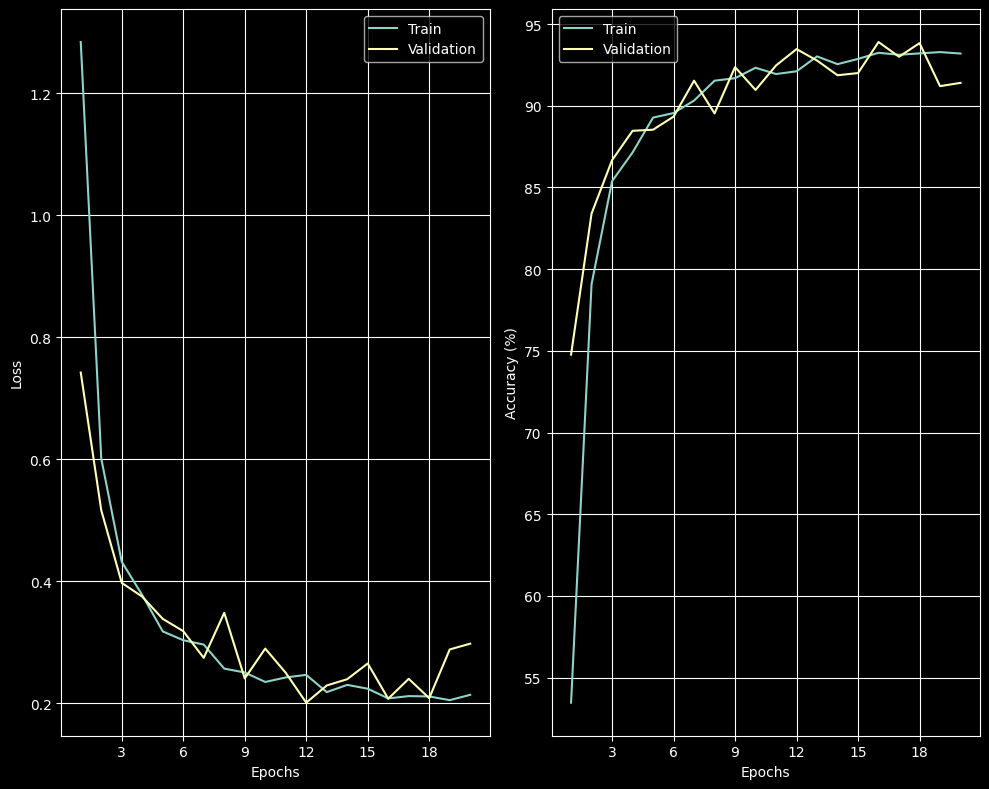

In [5]:
if __name__ == '__main__':
    dataset = SpikeDataset(INPUT_DIR)
    train_dataloader, val_dataloader, test_dataloader = get_split_dataloaders(dataset)

    # Get one batch from the training loader and make sure it looks good
    features, labels = next(iter(train_dataloader))
    print(f'Features shape: {features.shape}')
    print(f'Labels shape: {labels.shape}')
    print()

    # Load hyperparameters
    hyperparameters = json.load(open(HYPERPARAMETERS_PATH, 'r'))
    print(f'Hyperparameters used: {hyperparameters}')
    print()

    model = SNN1DEncodedClassifier(beta_init=hyperparameters['beta_init'], slope=hyperparameters['slope']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparameters['lr'])
    criterion = nn.CrossEntropyLoss()

    print(f'Training {model.NAME}...')
    best_acc = 0.0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    for epoch in range(NUM_EPOCHS):
        print(f'[Epoch {epoch + 1}/{NUM_EPOCHS}]')
        train_loss, train_acc = train_one_epoch_snn(device, model, criterion, optimizer, train_dataloader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_loss, val_acc = validate_snn(device, model, criterion, val_dataloader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)

        print(f'Train Loss: {train_loss:.2f} | Train Accuracy: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Accuracy: {val_acc:.2f}%')
        print()

    print(f'Best model had an accuracy of {best_acc:.2f}%.')
    print(f'Running final test...')
    model.load_state_dict(torch.load(MODEL_PATH))

    test_accuracy, avg_acs_per_inference, _ = benchmark_snn(device, model, test_dataloader)
    print(f'Test Accuracy: {test_accuracy:.2f}% | Average ACs per Inference: {avg_acs_per_inference}')

    plot_training_history(train_losses, train_accs, val_losses, val_accs)